# Import Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap

# Data Reading and Understanding

In [2]:
#read DataSet
df = pd.read_csv("train.csv")

In [3]:
# Show dataset shape
df.shape

(1460, 81)

In [4]:
# Display first rows of the dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
#Print columns NAMES
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [6]:
# Show dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
# Check missing values
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
# Show only columns that contain missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print(missing_cols)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [9]:
# Summary statistics of numerical features
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
# Identify numerical and categorical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Number of numerical features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

Number of numerical features: 38
Number of categorical features: 43


In [11]:
# Check target variable uniqueness
df["SalePrice"].nunique()

663

# EDA

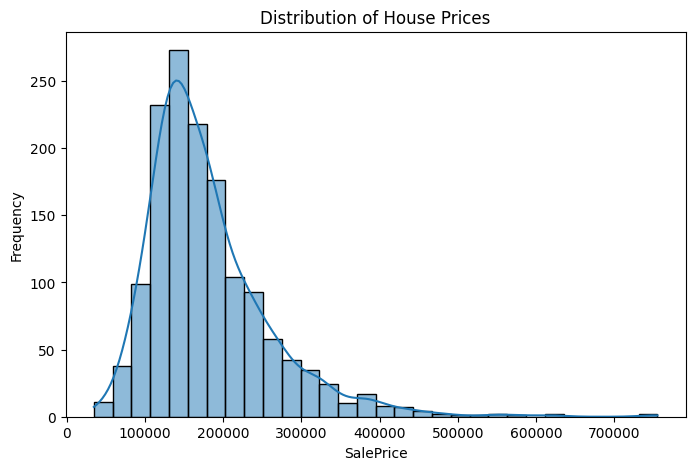

In [12]:
# Plot histogram for the target variable (SalePrice) To Check if the target class Balanced or not ( WE want imbalanced dataset)
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()


### The histogram shows that the target variable (SalePrice) is right-skewed. 
### Most houses have moderate prices while a smaller number of houses have very high prices.

In [13]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Get features most correlated with SalePrice
corr_with_target = corr_matrix["SalePrice"].sort_values(ascending=False)

print(corr_with_target.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


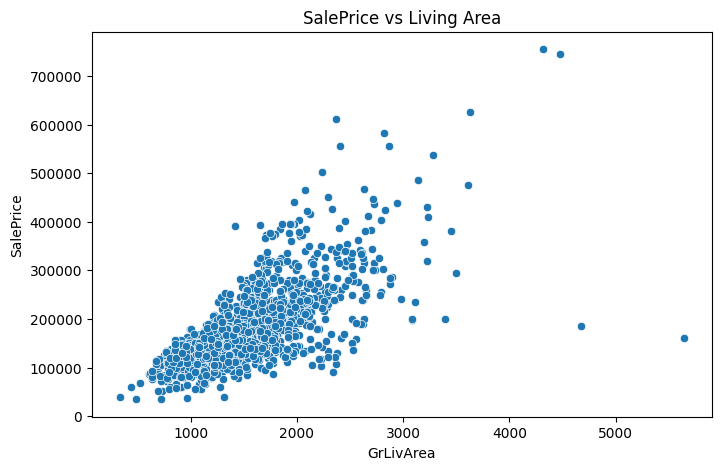

In [14]:
# Scatter plot between living area and sale price
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

plt.title("SalePrice vs Living Area")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()


### Positive relationship between living area (GrLivArea) and house sale price (SalePrice)

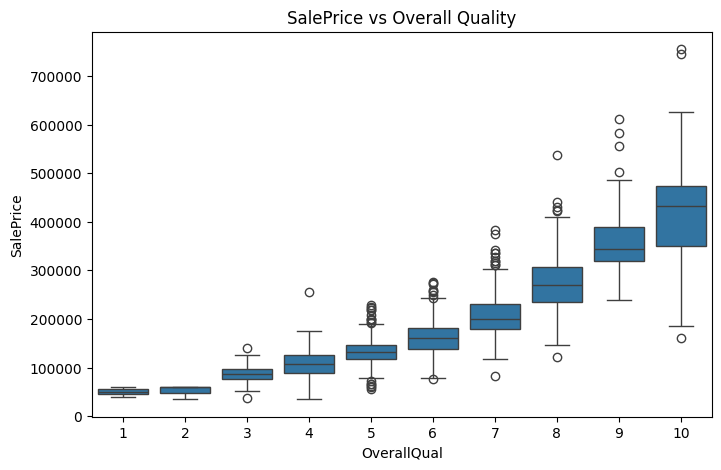

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])

plt.title("SalePrice vs Overall Quality")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")

plt.show()



### The plot shows a clear positive relationship between house overall quality and sale price.
### As the overall quality increases, the median house price also increases significantly.

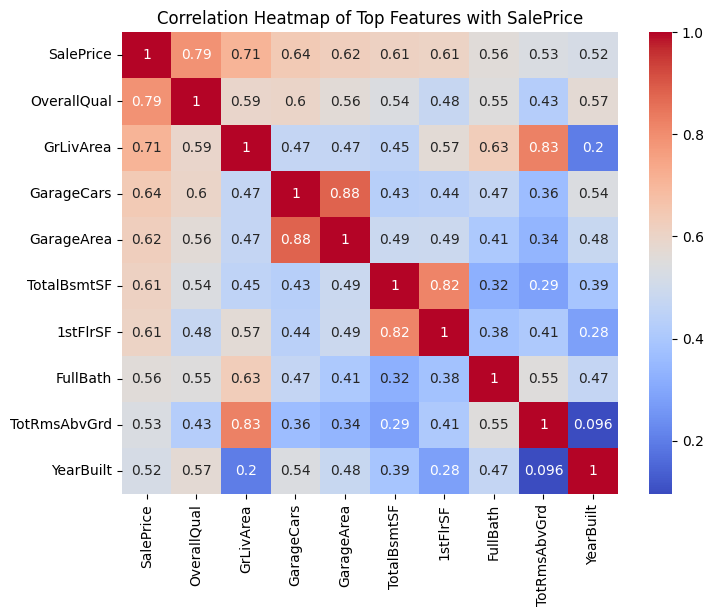

In [16]:
# Get correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Select top 10 features most correlated with SalePrice
top_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index

# Compute correlation matrix for these features
corr_top = df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_top, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Top Features with SalePrice")

plt.show()

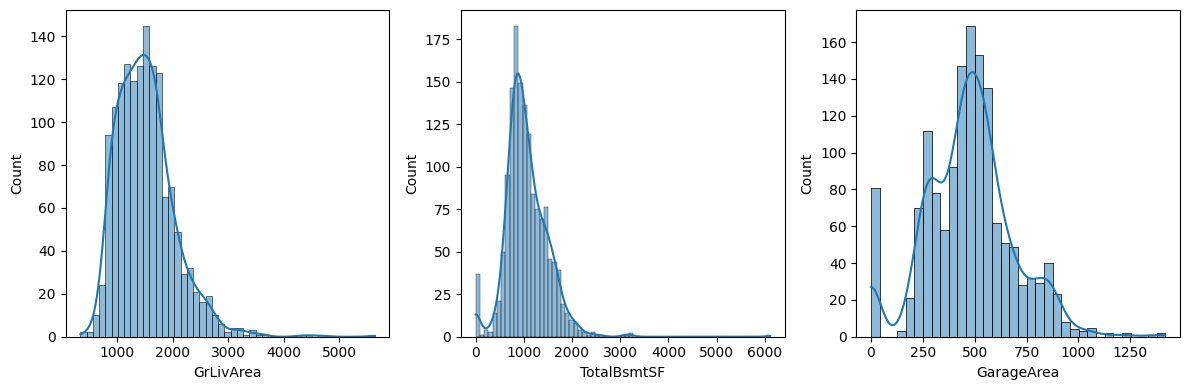

In [17]:
# Distribution of important numerical features

features = ["GrLivArea", "TotalBsmtSF", "GarageArea"]

plt.figure(figsize=(12,4))

for i, col in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True)

plt.tight_layout()
plt.show()


### The distributions of GrLivArea, TotalBsmtSF, and GarageArea are right-skewed, indicating that most houses have moderate sizes while a few houses have very large values (outliers).


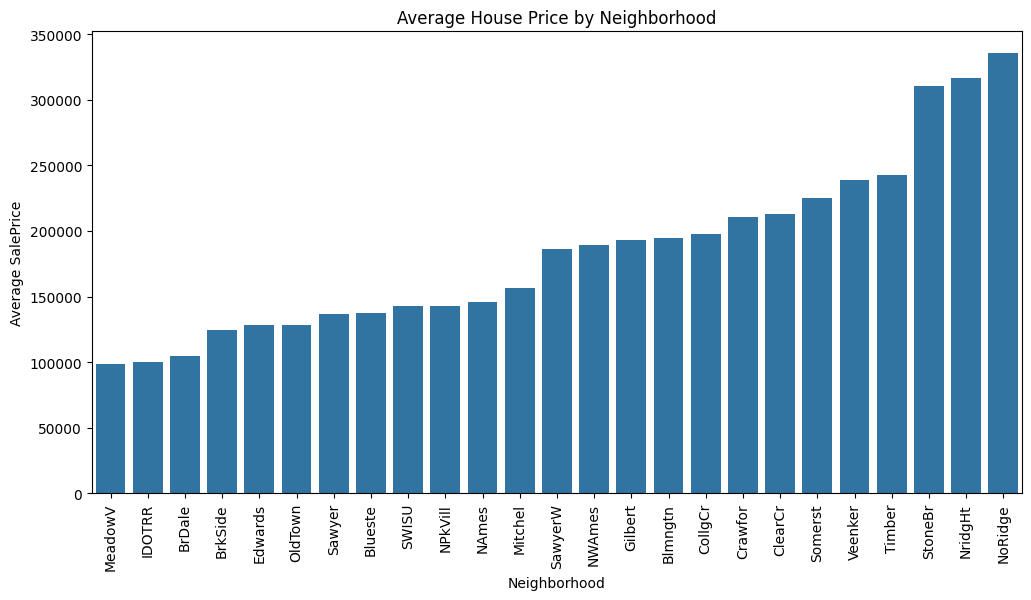

In [18]:
# Average house price by neighborhood

avg_price = df.groupby("Neighborhood")["SalePrice"].mean().sort_values()

plt.figure(figsize=(12,6))

sns.barplot(x=avg_price.index, y=avg_price.values)

plt.xticks(rotation=90)

plt.title("Average House Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average SalePrice")

plt.show()


### The bar plot shows that house prices vary significantly across neighborhoods. Areas such as NoRidge, NridgHt, and StoneBr have the highest average house prices, while MeadowV and IDOTRR have the lowest.

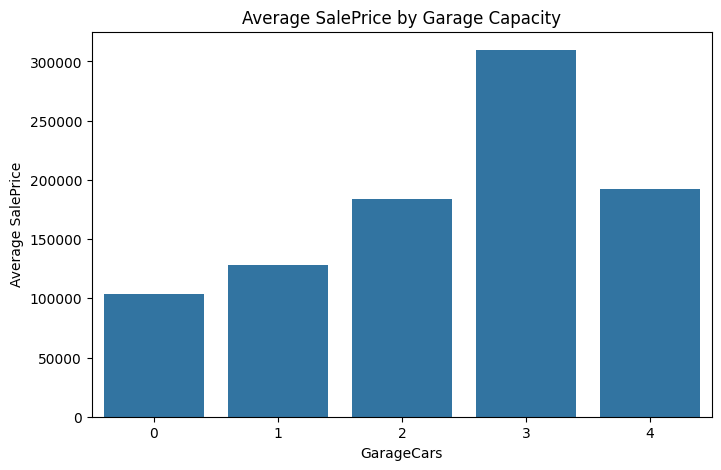

In [19]:
# Average house price by number of garage cars

avg_price = df.groupby("GarageCars")["SalePrice"].mean()

plt.figure(figsize=(8,5))

sns.barplot(x=avg_price.index, y=avg_price.values)

plt.title("Average SalePrice by Garage Capacity")
plt.xlabel("GarageCars")
plt.ylabel("Average SalePrice")

plt.show()


### The bar plot shows that houses with larger garage capacity generally have higher average sale prices. This indicates that garage size is an important factor influencing house prices.

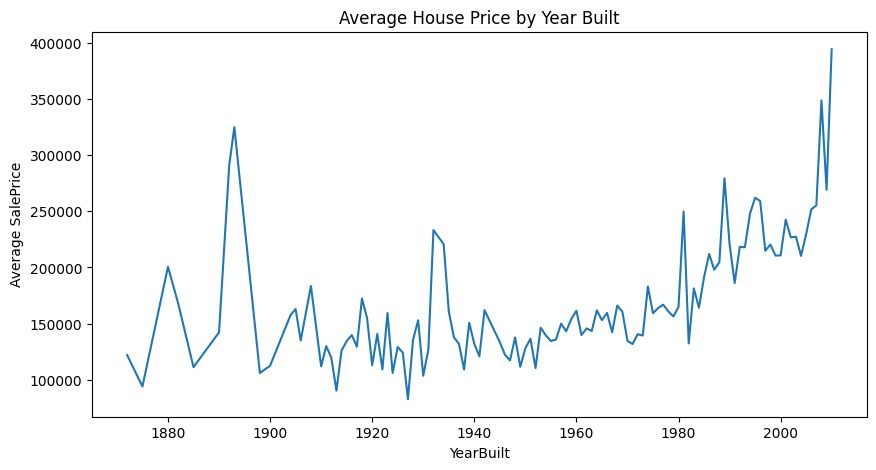

In [20]:
# Average house price by year built

avg_price_year = df.groupby("YearBuilt")["SalePrice"].mean()

plt.figure(figsize=(10,5))

plt.plot(avg_price_year.index, avg_price_year.values)

plt.title("Average House Price by Year Built")
plt.xlabel("YearBuilt")
plt.ylabel("Average SalePrice")

plt.show()


### Line chart showing the relationship between the year a house was built and the average sale price

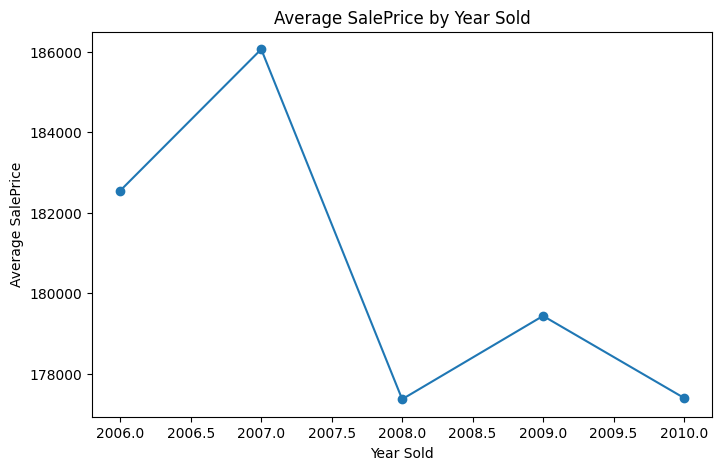

In [21]:
# Average house price by year sold

avg_price_year = df.groupby("YrSold")["SalePrice"].mean()

plt.figure(figsize=(8,5))

plt.plot(avg_price_year.index, avg_price_year.values, marker="o")

plt.title("Average SalePrice by Year Sold")
plt.xlabel("Year Sold")
plt.ylabel("Average SalePrice")

plt.show()


### Line chart showing how the average house sale price changes across different years

<Axes: ylabel='SalePrice'>

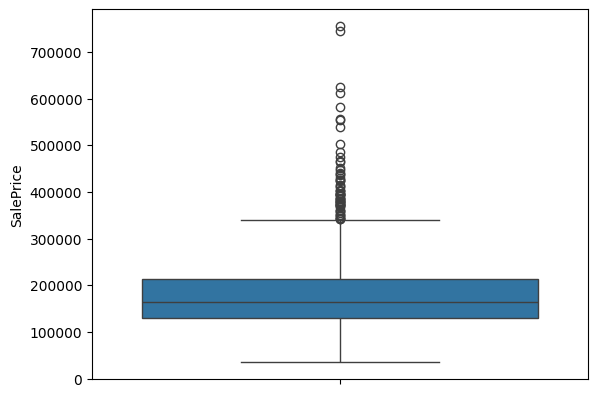

In [22]:
sns.boxplot(y=df["SalePrice"])
# Boxplot to detect outliers in the SalePrice distribution

# Data Cleaning and Preprocessing

### Handling Missing Values 

In [23]:
# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [24]:
# Remove features with extremely high missing values (more than 80%)
df.drop(columns=["PoolQC","MiscFeature","Alley","Fence"], inplace=True)

In [25]:
# Fill missing values for numerical features using median
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Fill missing values for categorical features using mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\alsha\AppData\Local\Temp\ipykernel_9488\383082297.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\alsha\AppData\Local\Temp\ipykernel_9488\383082297.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [26]:
# Check if there are any missing values left
print(df.isnull().sum().sum())

0


### Outliers

### Feature Encoding

In [27]:
# Identify categorical features
cat_cols = df.select_dtypes(include=['object']).columns

print(cat_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


In [28]:
# Convert categorical features into numerical features using One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [29]:
df.shape
# Dataset size after Featrue Encoding

(1460, 237)

### Data Type Summary After One-Hot Encoding

In [30]:
df.dtypes.value_counts()

bool       199
int64       35
float64      3
Name: count, dtype: int64

### check Duplicated rows

In [31]:
df.duplicated().sum()

0

### Removing the ID Column

In [32]:
# Create a copy of the dataset for dashboard or reference
df_with_id = df.copy()

# Remove Id column only for modeling
df = df.drop("Id", axis=1)

# Target Class

In [33]:
# Handle extreme values in SalePrice using clipping, then create balanced target classes
# by dividing the data into three quantile-based categories (Low, Medium, High)

df["SalePrice_trimmed"] = df["SalePrice"].clip(
    lower=df["SalePrice"].quantile(0.05),
    upper=df["SalePrice"].quantile(0.95)
)

df["SalePrice_Class"] = pd.qcut(
    df["SalePrice_trimmed"],
    q=3,
    labels=["Low", "Medium", "High"]
)

C:\Users\alsha\AppData\Local\Temp\ipykernel_9488\3637920007.py:4: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["SalePrice_trimmed"] = df["SalePrice"].clip(


### The SalePrice variable was first processed using clipping to reduce the impact of extreme values by limiting them within the 5th and 95th percentiles. Then, quantile-based binning was applied using pd.qcut to divide the data into three balanced categories: Low, Medium, and High.

In [34]:
# Count the number of observations in each target class
df["SalePrice_Class"].value_counts()

SalePrice_Class
Medium    490
Low       487
High      483
Name: count, dtype: int64

In [35]:
# Calculate the proportion (percentage) of each target class to check class balance
df["SalePrice_Class"].value_counts(normalize=True)

SalePrice_Class
Medium    0.335616
Low       0.333562
High      0.330822
Name: proportion, dtype: float64

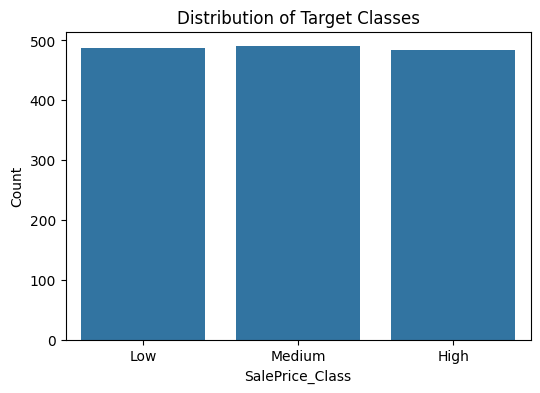

In [36]:
# Visualize the distribution of target classes
plt.figure(figsize=(6,4))
sns.countplot(x=df["SalePrice_Class"], order=["Low", "Medium", "High"])
plt.title("Distribution of Target Classes")
plt.xlabel("SalePrice_Class")
plt.ylabel("Count")
plt.show()

### The results show that the target classes are well-balanced, with approximately equal distribution across Low, Medium, and High categories.

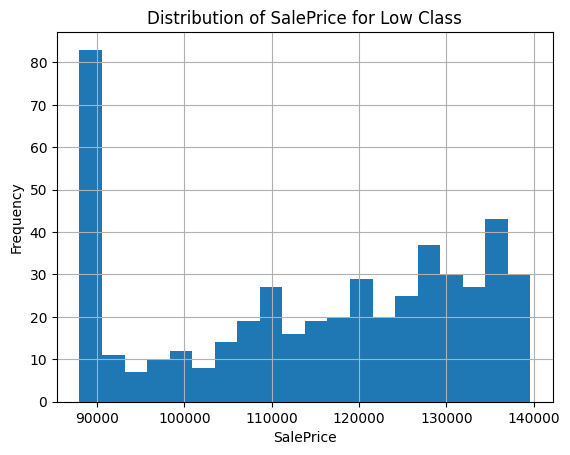

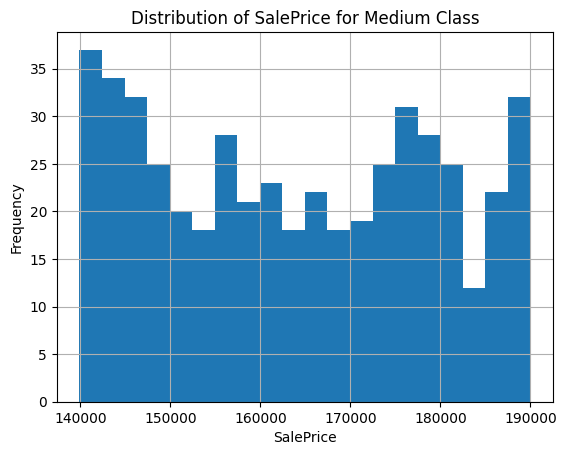

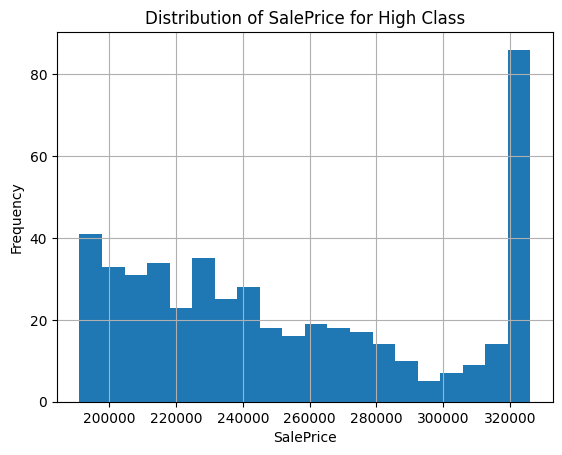

In [37]:
# Plot distribution for each class
for cls in ["Low", "Medium", "High"]:
    plt.figure()
    df[df["SalePrice_Class"] == cls]["SalePrice_trimmed"].hist(bins=20)
    plt.title(f"Distribution of SalePrice for {cls} Class")
    plt.xlabel("SalePrice")
    plt.ylabel("Frequency")
    plt.show()

### a) The distribution of the Low class shows a concentration of values near the lower boundary, with a noticeable spike caused by clipping of extreme low values.

### b) The Medium class exhibits a relatively uniform distribution across its range, indicating that the middle segment of the data is well spread without significant skewness.

### c) The High class displays a concentration of values near the upper boundary, where clipping has caused multiple high values to accumulate, resulting in a visible spike.

# Data Splitting

In [38]:
# Split the dataset into features (X) and target (y)
y = df["SalePrice_Class"]
X = df.drop(["SalePrice", "SalePrice_trimmed", "SalePrice_Class"], axis=1)


In [39]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### The dataset was split into training and testing sets using an 80/20 ratio, while preserving the class distribution through stratified sampling.

# Modeling 

In [40]:
# Combine X_train and y_train for splitting experts
train_data = X_train.copy()
train_data["SalePrice_Class"] = y_train

# Split into experts
train_low = train_data[train_data["SalePrice_Class"] == "Low"]
train_medium = train_data[train_data["SalePrice_Class"] == "Medium"]
train_high = train_data[train_data["SalePrice_Class"] == "High"]

# Split training data into subsets for each expert based on target class

### The training data was divided into three subsets based on the target classes (Low, Medium, High). This allows each model (expert) to specialize in learning patterns specific to its assigned class.

In [41]:
# Low expert
X_low = train_low.drop("SalePrice_Class", axis=1)
y_low = train_low["SalePrice_Class"]

# Medium expert
X_medium = train_medium.drop("SalePrice_Class", axis=1)
y_medium = train_medium["SalePrice_Class"]

# High expert
X_high = train_high.drop("SalePrice_Class", axis=1)
y_high = train_high["SalePrice_Class"]

### For each expert, the dataset was split into features (X) and target (y). The target column was separated from the input features to allow each model to be trained independently on its respective subset.

### Initialize Machine Learning Models:

In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

### Model Training and Evaluation:

In [44]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"{name} Accuracy:", acc)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7842465753424658
Random Forest Accuracy: 0.815068493150685
Gradient Boosting Accuracy: 0.821917808219178
CatBoost Accuracy: 0.8321917808219178


### The results show that CatBoost achieved the best performance, followed by Gradient Boosting and Random Forest, while Logistic Regression had the lowest accuracy. Therefore, CatBoost was selected as the final model for the Mixture of Experts approach.

# mixture of experts

### 1) Train the gating model

In [45]:
# Train the gating model using the full training data
gating_model = CatBoostClassifier(verbose=0, random_state=42)
gating_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

### 2) Create one-vs-rest targets for each expert

In [46]:
# Create binary targets for each expert
y_train_low = (y_train == "Low").astype(int)
y_train_medium = (y_train == "Medium").astype(int)
y_train_high = (y_train == "High").astype(int)

### 3) Train the expert models

In [47]:
# Train one-vs-rest expert models
expert_low = CatBoostClassifier(verbose=0, random_state=42)
expert_medium = CatBoostClassifier(verbose=0, random_state=42)
expert_high = CatBoostClassifier(verbose=0, random_state=42)

expert_low.fit(X_train, y_train_low)
expert_medium.fit(X_train, y_train_medium)
expert_high.fit(X_train, y_train_high)

CatBoostClassifier(random_state=42, verbose=0)

### 4) Get probabilities from gating model and experts

In [48]:
# Get class probabilities from the gating model
gating_probs = gating_model.predict_proba(X_test)
gating_classes = gating_model.classes_

# Convert gating probabilities into a DataFrame for easier access
gating_df = pd.DataFrame(gating_probs, columns=gating_classes, index=X_test.index)

# Get positive-class probabilities from each expert
low_probs = expert_low.predict_proba(X_test)[:, 1]
medium_probs = expert_medium.predict_proba(X_test)[:, 1]
high_probs = expert_high.predict_proba(X_test)[:, 1]


### 5) Combine gating and expert probabilities

In [49]:
# Combine gating probabilities with expert probabilities
moe_scores = pd.DataFrame(index=X_test.index)

moe_scores["Low"] = gating_df["Low"] * low_probs
moe_scores["Medium"] = gating_df["Medium"] * medium_probs
moe_scores["High"] = gating_df["High"] * high_probs

# Final prediction is the class with the highest combined score
moe_predictions = moe_scores.idxmax(axis=1)

### 6) Evaluate the MoE model

In [50]:
# Evaluate Mixture of Experts performance
moe_accuracy = accuracy_score(y_test, moe_predictions)

print("MoE Accuracy:", moe_accuracy)
print(classification_report(y_test, moe_predictions))

MoE Accuracy: 0.8458904109589042
              precision    recall  f1-score   support

        High       0.88      0.96      0.92        97
         Low       0.86      0.82      0.84        97
      Medium       0.80      0.76      0.77        98

    accuracy                           0.85       292
   macro avg       0.84      0.85      0.84       292
weighted avg       0.84      0.85      0.84       292



# Evaluation

In [51]:
# Convert results dictionary to DataFrame
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

# Sort results from best to worst and reset the index
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Display results
print(results_df)

                 Model  Accuracy
0             CatBoost  0.832192
1    Gradient Boosting  0.821918
2        Random Forest  0.815068
3  Logistic Regression  0.784247


In [52]:
# Identify best baseline model
best_model = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("Best Baseline Model:", best_model)
print("Best Baseline Accuracy:", best_accuracy)

print("MoE Accuracy:", moe_accuracy)
print("Improvement:", moe_accuracy - best_accuracy)
# Compare the best baseline model with the Mixture of Experts model

Best Baseline Model: CatBoost
Best Baseline Accuracy: 0.8321917808219178
MoE Accuracy: 0.8458904109589042
Improvement: 0.013698630136986356


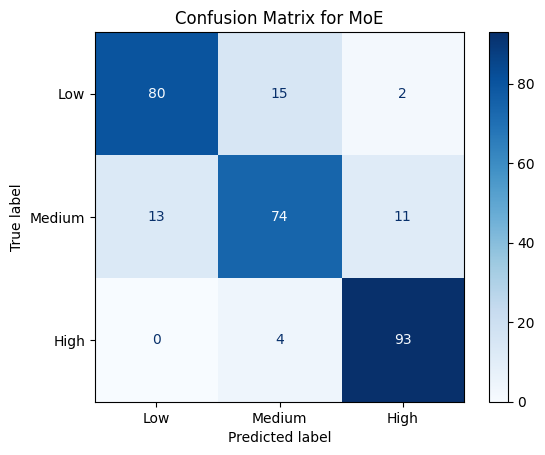

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, moe_predictions, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for MoE")
plt.show()

# Explainable AI (XAI)

In [54]:
# Create SHAP explainer for CatBoost
explainer = shap.Explainer(models["CatBoost"])

# Calculate SHAP values
shap_values = explainer(X_test)

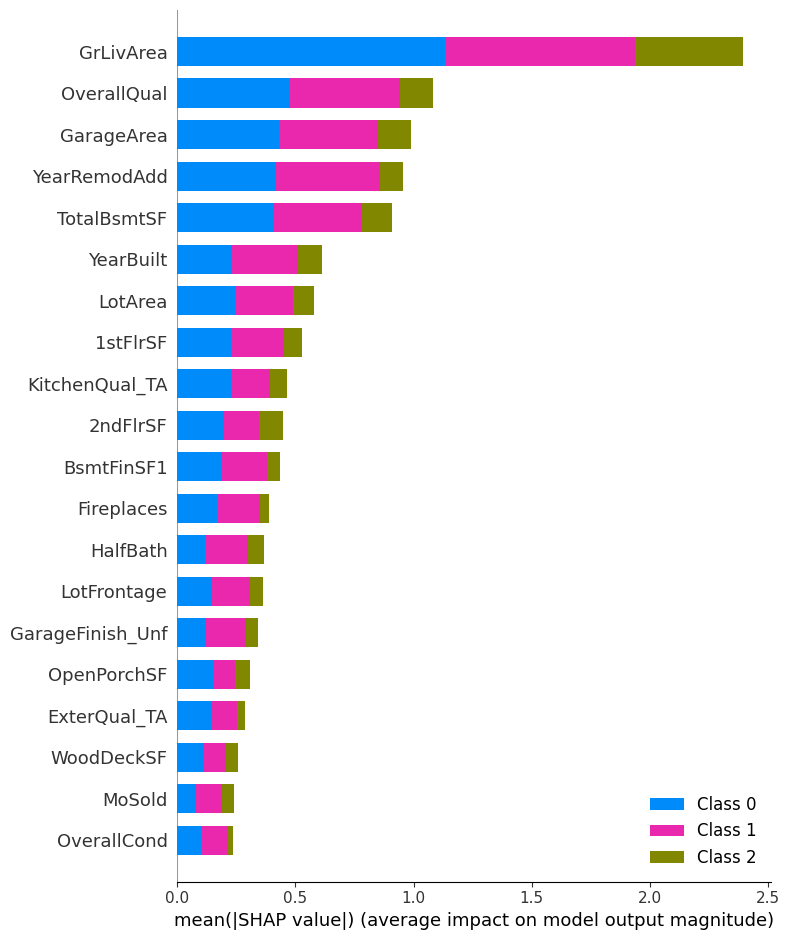

In [55]:
# Summary plot
shap.summary_plot(shap_values, X_test)

### Class 0 corresponds to "Low"
### Class 1 corresponds to "Medium"
### Class 2 corresponds to "High"

The SHAP summary plot shows the most important features affecting the model's predictions. Features at the top have the highest impact, and the length of each bar indicates how strongly each feature influences the output. The colors represent different classes (Low, Medium, High), highlighting how each feature contributes to each class differently.